## Computational Astrobiology – Project

In [1]:
### Preamble

%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

from IPython.display import HTML

import time, sys, warnings

import h5py

import matplotlib as mpl
import numpy as np
import sympy as sym

from sympy import init_printing
init_printing(use_latex=True)

from sympy.utilities.lambdify import lambdify

import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation, PillowWriter

from matplotlib.colors import ListedColormap
from matplotlib.legend_handler import HandlerTuple

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=["olivedrab", "steelblue", "firebrick", "goldenrod"]) 
plt.rcParams['figure.figsize'] = [8,5]
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True

N = 2**8

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(107/256, 1, N)
vals[:, 1] = np.linspace(142/256, 1, N)
vals[:, 2] = np.linspace(35/256, 1, N)

OliveDrab = ListedColormap(vals)
OliveDrab_r = OliveDrab.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(70/256, 1, N)
vals[:, 1] = np.linspace(130/256, 1, N)
vals[:, 2] = np.linspace(180/256, 1, N)

SteelBlue = ListedColormap(vals)
SteelBlue_r = SteelBlue.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(178/256, 1, N)
vals[:, 1] = np.linspace(34/256, 1, N)
vals[:, 2] = np.linspace(34/256, 1, N)

FireBrick = ListedColormap(vals)
FireBrick_r = FireBrick.reversed()

vals = np.ones((N, 4))
vals[:, 0] = np.linspace(218/256, 1, N)
vals[:, 1] = np.linspace(165/256, 1, N)
vals[:, 2] = np.linspace(32/256, 1, N)

GoldenRod = ListedColormap(vals)
GoldenRod_r = GoldenRod.reversed()

grid_v0.1_ov0_001000 | Group      | 5
grid_v0.1_ov0_001002 | Group      | 5
grid_v0.1_ov0_001003 | Group      | 5
grid_v0.1_ov0_001006 | Group      | 5
grid_v0.1_ov0_001007 | Group      | 5
grid_v0.1_ov0_001008 | Group      | 5
grid_v0.1_ov0_001010 | Group      | 5
grid_v0.1_ov0_001012 | Group      | 5
grid_v0.1_ov0_001013 | Group      | 5
grid_v0.1_ov0_001014 | Group      | 5
grid_v0.1_ov0_001015 | Group      | 5
grid_v0.1_ov0_001018 | Group      | 5
grid_v0.1_ov0_001020 | Group      | 5
grid_v0.1_ov0_001021 | Group      | 5
grid_v0.1_ov0_001024 | Group      | 5
grid_v0.1_ov0_001025 | Group      | 5
grid_v0.1_ov0_001026 | Group      | 5
grid_v0.1_ov0_001027 | Group      | 5
grid_v0.1_ov0_001028 | Group      | 5
grid_v0.1_ov0_001030 | Group      | 5
grid_v0.1_ov0_001032 | Group      | 5
grid_v0.1_ov0_001034 | Group      | 5
grid_v0.1_ov0_001036 | Group      | 5
grid_v0.1_ov0_001037 | Group      | 5
grid_v0.1_ov0_001038 | Group      | 5
grid_v0.1_ov0_001040 | Group      | 5
grid_v0.1_ov

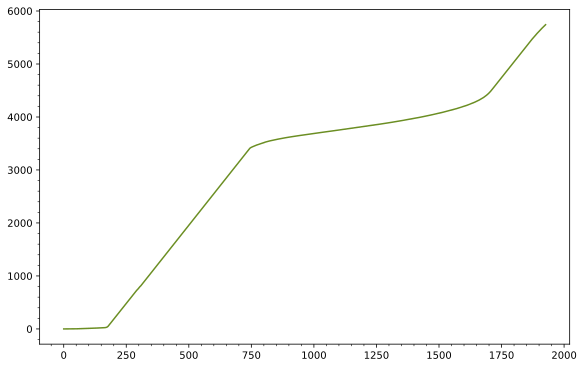

Metadata: {'label': 'radius', 'units': 'cm'}
Shape: (1927,), Type: float64
243720430130.19852


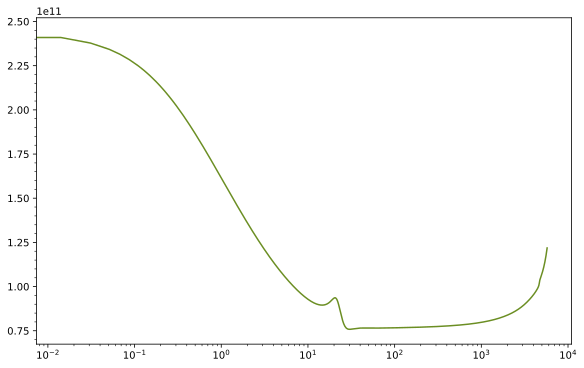

Metadata: {'label': 'luminosity', 'units': ''}
Shape: (1927,), Type: float64
1.6962430540581293e+34


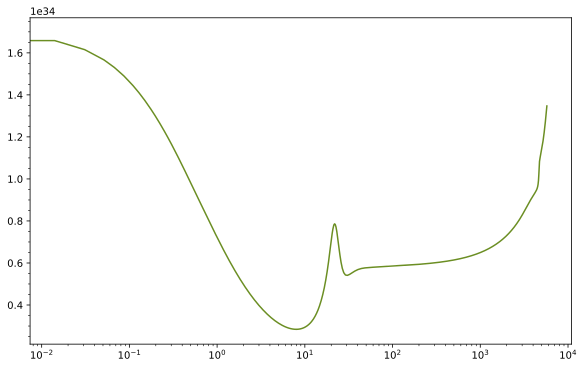

Metadata: {'label': 'logg', 'units': ''}
Shape: (1927,), Type: float64
3.423685007352837


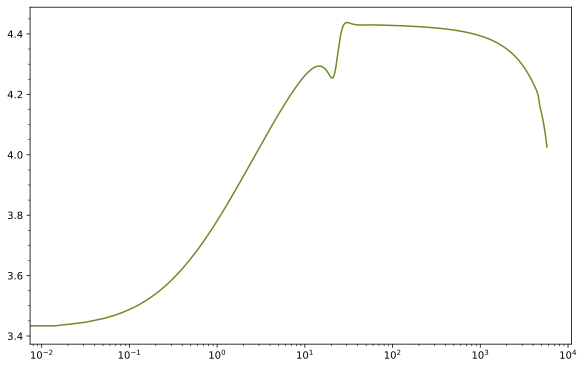

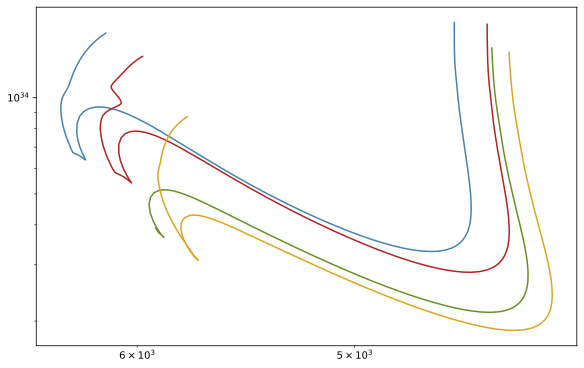

97 [1.794229219263e+33,2.3767711735687632e+33]


In [2]:
with h5py.File('grid.hdf5', 'r') as f:
    for name in list(f.keys()):
        item = f[name]
        kind = "Group" if isinstance(item, h5py.Group) else "Dataset"
        detail = len(item) if kind == "Group" else item.shape
        print(f"{name:20} | {kind:10} | {detail}")
    print()
    for name in list(f['grid_v0.1_ov0_001000'].keys()):
        item = f['grid_v0.1_ov0_001000'][name]
        kind = "Group" if isinstance(item, h5py.Group) else "Dataset"
        detail = len(item) if kind == "Group" else item.shape
        print(f"{name:20} | {kind:10} | {detail}")
    print()
    for name in list(f['grid_v0.1_ov0_001000/global'].keys()):
        item = f['grid_v0.1_ov0_001000/global'][name]
        kind = "Group" if isinstance(item, h5py.Group) else "Dataset"
        detail = len(item) if kind == "Group" else item.shape
        print(f"{name:20} | {kind:10} | {detail}")
    print()
    dataset = f['grid_v0.1_ov0_001073/global/mass']
    print("Metadata:", dict(dataset.attrs))
    print(f"Shape: {dataset.shape}, Type: {dataset.dtype}")
    print(dataset[0])
    print()
    dataset = f['grid_v0.1_ov0_001073/global/age']
    print("Metadata:", dict(dataset.attrs))
    print(f"Shape: {dataset.shape}, Type: {dataset.dtype}")
    print(dataset[0])
    plt.plot(dataset[:])
    plt.show()
    plt.close()
    t = dataset[:]
    dataset = f['grid_v0.1_ov0_001073/global/radius']
    print("Metadata:", dict(dataset.attrs))
    print(f"Shape: {dataset.shape}, Type: {dataset.dtype}")
    print(dataset[0])
    plt.plot(t, dataset[:])
    plt.xscale('log')
    plt.show()
    plt.close()
    dataset = f['grid_v0.1_ov0_001073/global/lum']
    print("Metadata:", dict(dataset.attrs))
    print(f"Shape: {dataset.shape}, Type: {dataset.dtype}")
    print(dataset[0])
    plt.plot(t, dataset[:])
    plt.xscale('log')
    plt.show()
    plt.close()
    dataset = f['grid_v0.1_ov0_001073/global/logg']
    print("Metadata:", dict(dataset.attrs))
    print(f"Shape: {dataset.shape}, Type: {dataset.dtype}")
    print(dataset[0])
    plt.plot(t, dataset[:])
    plt.xscale('log')
    plt.show()
    plt.close()
    x1 = f['grid_v0.1_ov0_001000/global/teff'][:]
    y1 = f['grid_v0.1_ov0_001000/global/lum'][:]
    x2 = f['grid_v0.1_ov0_001025/global/teff'][:]
    y2 = f['grid_v0.1_ov0_001025/global/lum'][:]
    x3 = f['grid_v0.1_ov0_001073/global/teff'][:]
    y3 = f['grid_v0.1_ov0_001073/global/lum'][:]
    x4 = f['grid_v0.1_ov0_001147/global/teff'][:]
    y4 = f['grid_v0.1_ov0_001147/global/lum'][:]
    plt.plot(x1, y1)
    plt.plot(x2, y2)
    plt.plot(x3, y3)
    plt.plot(x4, y4)
    plt.xscale('log')
    plt.yscale('log')
    plt.gca().invert_xaxis()
    plt.show()
    plt.close()
    keys = sorted(f.keys())
    targets = keys[:-1]
    m = np.array([f[key]['global/mass'][0] for key in targets])
    print(f"{len(m)} [{m.min()},{m.max()}]")